# XGBoost no LAG

[0]	validation_0-rmse:804.43721
[1]	validation_0-rmse:768.39227
[2]	validation_0-rmse:735.57769
[3]	validation_0-rmse:705.59108
[4]	validation_0-rmse:678.67921
[5]	validation_0-rmse:652.42174
[6]	validation_0-rmse:627.70393
[7]	validation_0-rmse:605.46187
[8]	validation_0-rmse:585.68946
[9]	validation_0-rmse:567.56962
[10]	validation_0-rmse:553.10293
[11]	validation_0-rmse:537.70483
[12]	validation_0-rmse:524.68573
[13]	validation_0-rmse:524.09962
[14]	validation_0-rmse:514.38706
[15]	validation_0-rmse:504.93058
[16]	validation_0-rmse:495.74687
[17]	validation_0-rmse:488.26884
[18]	validation_0-rmse:481.65036
[19]	validation_0-rmse:479.45537
[20]	validation_0-rmse:473.69947
[21]	validation_0-rmse:469.03028
[22]	validation_0-rmse:465.36265
[23]	validation_0-rmse:462.53122
[24]	validation_0-rmse:460.11825
[25]	validation_0-rmse:458.15063
[26]	validation_0-rmse:456.96024
[27]	validation_0-rmse:456.56272
[28]	validation_0-rmse:456.17198
[29]	validation_0-rmse:456.43299
[30]	validation_0-rm

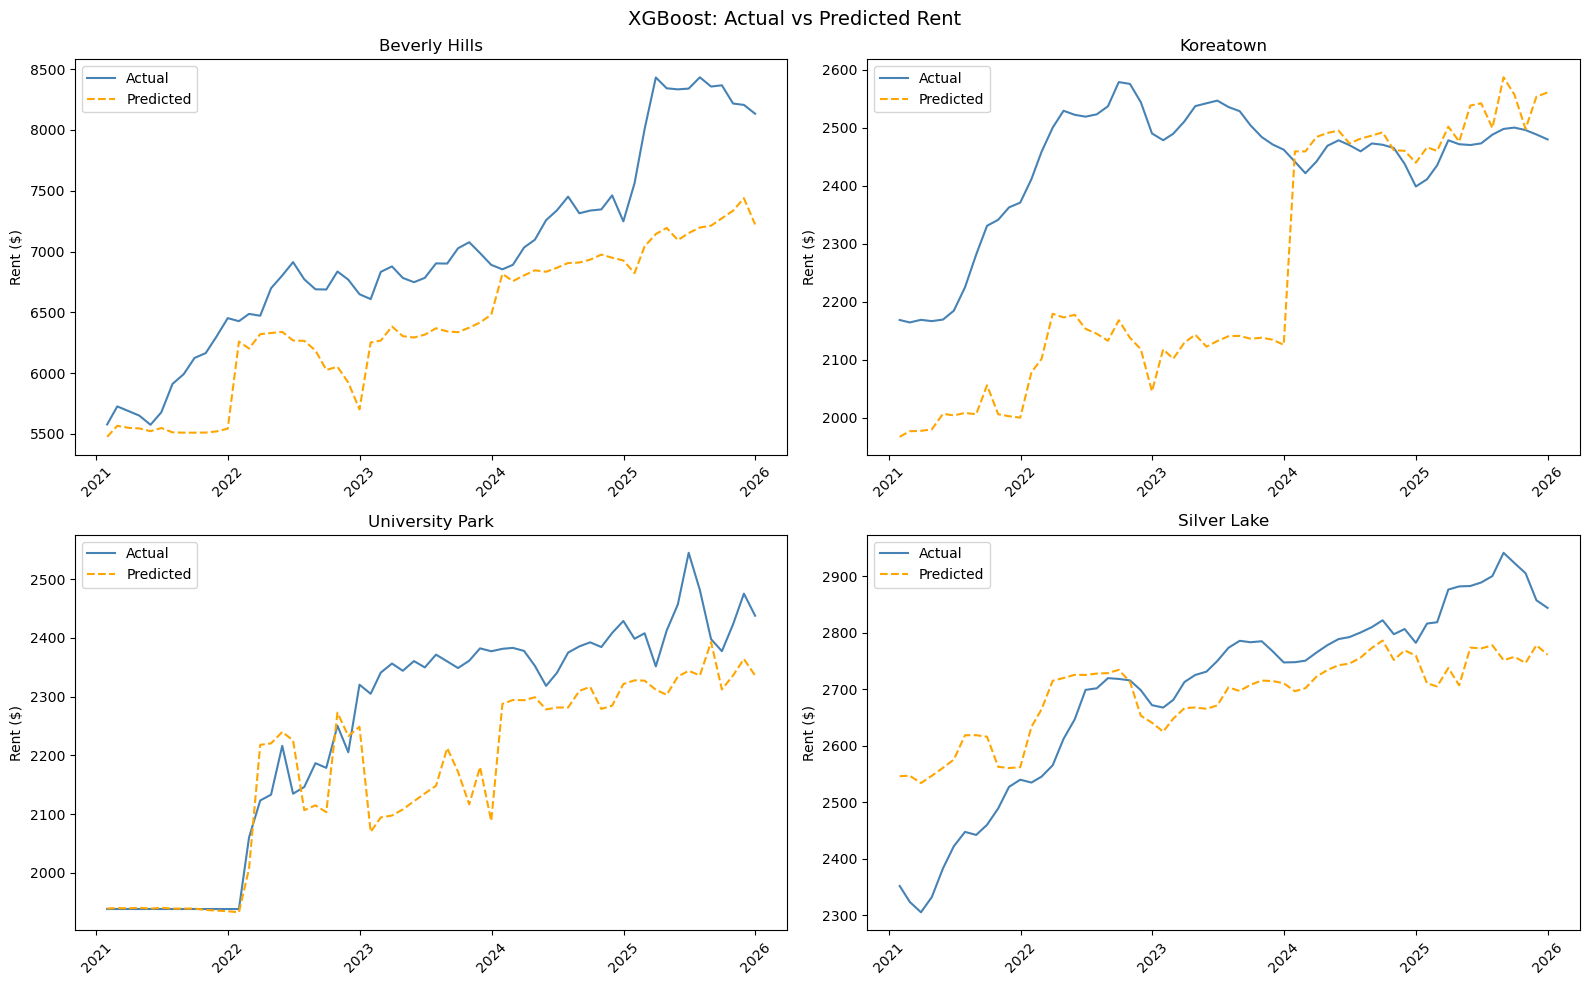

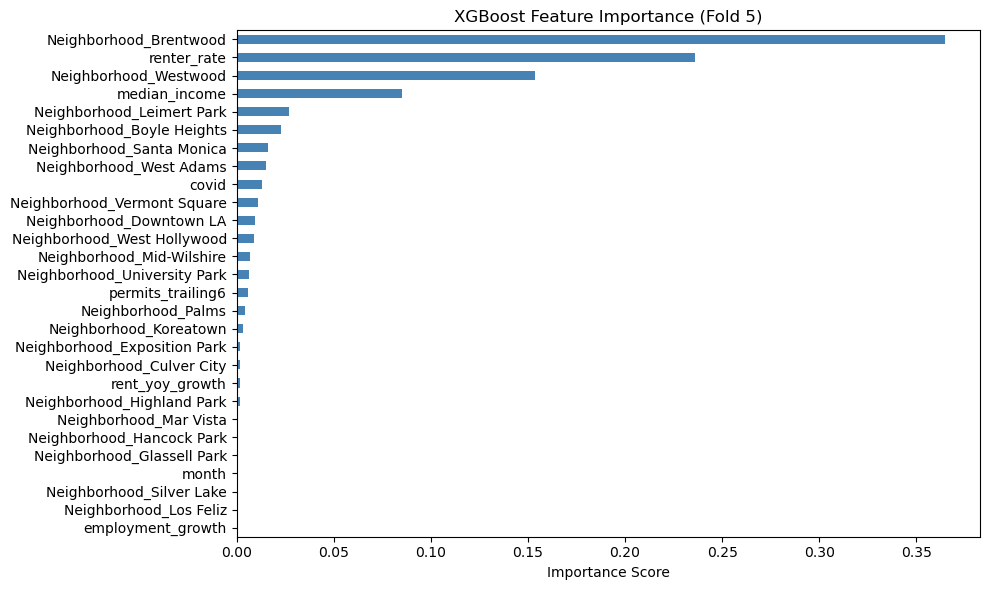

Predictions saved. Shape: (1320, 35)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── Load data ─────────────────────────────────────────────────────────────────
master = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master_model.csv')
master['Date'] = pd.to_datetime(master['Date'])
master = master.sort_values(['Neighborhood', 'Date']).reset_index(drop=True)


master = pd.get_dummies(master, columns=['Neighborhood'], drop_first=True)

# Update FEATURES to include all dummy columns
neighborhood_cols = [c for c in master.columns if c.startswith('Neighborhood_')]

# ── Features and target ───────────────────────────────────────────────────────
FEATURES = neighborhood_cols + [
    'permits_trailing6', 'employment_growth', 'median_income',
    'covid', 'month', 'rent_yoy_growth', 'renter_rate'
]

TARGET = 'Rent'

# ── Walk-forward cross validation ─────────────────────────────────────────────
# 5 expanding folds
# Fold 1: train 2020, test 2021
# Fold 2: train 2020-2021, test 2022
# Fold 3: train 2020-2022, test 2023
# Fold 4: train 2020-2023, test 2024
# Fold 5: train 2020-2024, test 2025

folds = [
    ('2020-01-01', '2020-12-31', '2021-01-01', '2021-12-31'),
    ('2020-01-01', '2021-12-31', '2022-01-01', '2022-12-31'),
    ('2020-01-01', '2022-12-31', '2023-01-01', '2023-12-31'),
    ('2020-01-01', '2023-12-31', '2024-01-01', '2024-12-31'),
    ('2020-01-01', '2024-12-31', '2025-01-01', '2025-12-31'),
]

fold_results = []
all_predictions = []

for i, (train_start, train_end, test_start, test_end) in enumerate(folds):
    # Split
    train = master[(master['Date'] >= train_start) & (master['Date'] <= train_end)]
    test  = master[(master['Date'] >= test_start)  & (master['Date'] <= test_end)]
    
    X_train, y_train = train[FEATURES], train[TARGET]
    X_test,  y_test  = test[FEATURES],  test[TARGET]
    
    # Train XGBoost
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              )
    
    # Predict
    preds = model.predict(X_test)
    
    # Metrics
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    
    fold_results.append({
        'Fold': i + 1,
        'Train period': f"{train_start[:7]} → {train_end[:7]}",
        'Test period':  f"{test_start[:7]} → {test_end[:7]}",
        'MAE':  round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2)
    })
    
    # Store predictions with metadata
    test_copy = test.copy()
    test_copy['predicted_rent'] = preds
    test_copy['residual'] = test_copy[TARGET] - test_copy['predicted_rent']
    test_copy['fold'] = i + 1
    all_predictions.append(test_copy)
    
    print(f"Fold {i+1} | MAE: ${mae:.0f} | RMSE: ${rmse:.0f} | MAPE: {mape:.2f}%")

# ── Results summary ───────────────────────────────────────────────────────────
results_df = pd.DataFrame(fold_results)
print(f"\n── Cross Validation Results ──")
print(results_df.to_string(index=False))
print(f"\nMean MAE:  ${results_df['MAE'].mean():.0f}")
print(f"Mean RMSE: ${results_df['RMSE'].mean():.0f}")
print(f"Mean MAPE: {results_df['MAPE'].mean():.2f}%")

# ── Combine all predictions ───────────────────────────────────────────────────
predictions_df = pd.concat(all_predictions, ignore_index=True)
print(f"\nTotal predictions: {len(predictions_df)}")

# ── Plot: Actual vs Predicted for sample neighborhoods ────────────────────────
sample_neighborhoods = ['Beverly Hills', 'Koreatown', 'University Park', 'Silver Lake']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, neighborhood in enumerate(sample_neighborhoods):
    ax = axes[i]
    # Use Neighborhood_ dummy column instead
    col = f'Neighborhood_{neighborhood}'
    nd = predictions_df[predictions_df[col] == 1] if col in predictions_df.columns else predictions_df.iloc[0:0]
    
    # Fallback for drop_first — Beverly Hills may have been dropped
    if nd.empty:
        # Beverly Hills is the reference category (dropped), filter by exclusion
        other_cols = [c for c in predictions_df.columns if c.startswith('Neighborhood_')]
        nd = predictions_df[predictions_df[other_cols].sum(axis=1) == 0]
    
    ax.plot(nd['Date'], nd['Rent'], label='Actual', color='steelblue')
    ax.plot(nd['Date'], nd['predicted_rent'], label='Predicted',
            color='orange', linestyle='--')
    ax.set_title(neighborhood)
    ax.legend()
    ax.set_ylabel('Rent ($)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('XGBoost: Actual vs Predicted Rent', fontsize=14)
plt.tight_layout()
plt.savefig('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/visualizations/xgb_actual_vs_predicted.png', dpi=150)
plt.show()

# ── Feature importance ────────────────────────────────────────────────────────
# Use last fold's model for feature importance
fig, ax = plt.subplots(figsize=(10, 6))
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance (Fold 5)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/visualizations/xgb_feature_importance.png', dpi=150)
plt.show()

# ── Save final XGBoost predictions ───────────────────────────────────────────
predictions_df.to_csv(
    '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/model_csv/xgb_final_predictions.csv',
    index=False
)
print(f"Predictions saved. Shape: {predictions_df.shape}")

# PROPHET

Beverly Hills | MAE: $393 | MAPE: 5.40%
Boyle Heights | MAE: $118 | MAPE: 5.32%
Brentwood | MAE: $130 | MAPE: 3.52%
Culver City | MAE: $119 | MAPE: 3.76%
Downtown LA | MAE: $128 | MAPE: 4.92%
Exposition Park | MAE: $51 | MAPE: 2.14%
Glassell Park | MAE: $79 | MAPE: 2.94%
Hancock Park | MAE: $99 | MAPE: 4.43%
Highland Park | MAE: $81 | MAPE: 2.99%
Koreatown | MAE: $173 | MAPE: 6.97%
Leimert Park | MAE: $85 | MAPE: 4.02%
Los Feliz | MAE: $109 | MAPE: 4.23%
Mar Vista | MAE: $137 | MAPE: 4.51%
Mid-Wilshire | MAE: $218 | MAPE: 7.69%
Palms | MAE: $124 | MAPE: 4.78%
Santa Monica | MAE: $113 | MAPE: 3.30%
Silver Lake | MAE: $111 | MAPE: 4.06%
University Park | MAE: $145 | MAPE: 6.27%
Vermont Square | MAE: $127 | MAPE: 5.60%
West Adams | MAE: $100 | MAPE: 3.56%
West Hollywood | MAE: $123 | MAPE: 3.97%
Westwood | MAE: $136 | MAPE: 3.59%

── Prophet Per-Neighborhood Results (Fixed) ──
   Neighborhood  Mean MAE  Mean RMSE  Mean MAPE
Exposition Park     50.58      66.06       2.14
  Glassell Park  

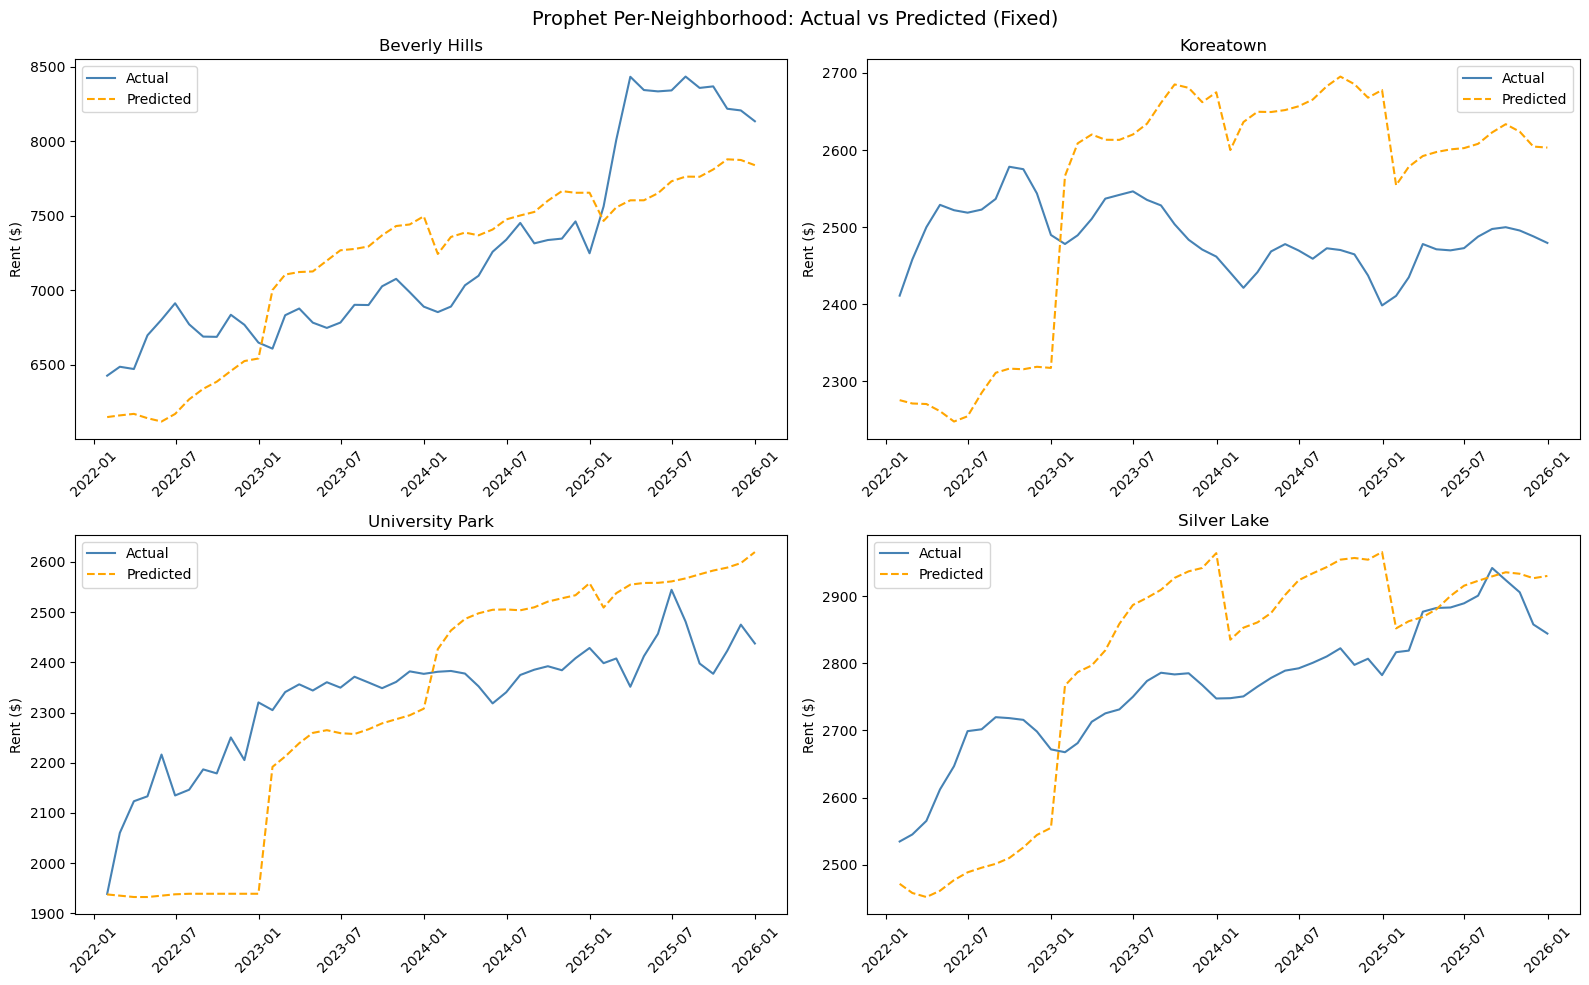


Predictions saved. Shape: (1056, 17)


In [35]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import logging
import warnings
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# ── Load data ─────────────────────────────────────────────────────────────────
master = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master_model.csv')
master['Date'] = pd.to_datetime(master['Date'])
master = master.sort_values(['Neighborhood', 'Date']).reset_index(drop=True)

# ── Walk-forward folds ────────────────────────────────────────────────────────
folds = [
    ('2020-01-01', '2020-12-31', '2021-01-01', '2021-12-31'),
    ('2020-01-01', '2021-12-31', '2022-01-01', '2022-12-31'),
    ('2020-01-01', '2022-12-31', '2023-01-01', '2023-12-31'),
    ('2020-01-01', '2023-12-31', '2024-01-01', '2024-12-31'),
    ('2020-01-01', '2024-12-31', '2025-01-01', '2025-12-31'),
]

neighborhoods = sorted(master['Neighborhood'].unique())

all_predictions = []
neighborhood_metrics = []

# ── Train Prophet per neighborhood per fold ───────────────────────────────────
for neighborhood in neighborhoods:
    nd_data = master[master['Neighborhood'] == neighborhood].copy()
    nd_data = nd_data.rename(columns={'Date': 'ds', 'Rent': 'y'})

    fold_maes, fold_rmses, fold_mapes = [], [], []

    for i, (train_start, train_end, test_start, test_end) in enumerate(folds):
        train = nd_data[(nd_data['ds'] >= train_start) & (nd_data['ds'] <= train_end)].copy()
        test  = nd_data[(nd_data['ds'] >= test_start)  & (nd_data['ds'] <= test_end)].copy()

        # Fix 1 — require at least 18 months of training data
        if len(train) < 18 or len(test) == 0:
            continue

        # Fix 2 — add floor and cap per neighborhood
        floor = train['y'].min() * 0.7
        cap   = train['y'].max() * 1.5

        train['floor'] = floor
        train['cap']   = cap
        test['floor']  = floor
        test['cap']    = cap

        # ── Fit Prophet with logistic growth ─────────────────────────────────
        m = Prophet(
            growth='logistic',
            yearly_seasonality=False,   # disable automatic yearly seasonality
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='additive',  # additive is more stable than multiplicative
            changepoint_prior_scale=0.05, # less flexible trend — reduce from 0.1
            )

        # Add yearly seasonality manually with fewer Fourier terms
        m.add_seasonality(
            name='yearly',
            period=365.25,
            fourier_order=3  # default is 10 — reducing smooths out the seasonality
            )

        m.fit(train[['ds', 'y', 'floor', 'cap']])

        # ── Predict ───────────────────────────────────────────────────────────
        future = test[['ds', 'floor', 'cap']].copy()
        forecast = m.predict(future)

        preds  = forecast['yhat'].values
        actual = test['y'].values

        mae  = mean_absolute_error(actual, preds)
        rmse = np.sqrt(mean_squared_error(actual, preds))
        mape = np.mean(np.abs((actual - preds) / actual)) * 100

        fold_maes.append(mae)
        fold_rmses.append(rmse)
        fold_mapes.append(mape)

        # Store predictions
        test_copy = test.copy()
        test_copy['predicted_rent'] = preds
        test_copy['residual']       = test_copy['y'] - test_copy['predicted_rent']
        test_copy['fold']           = i + 1
        test_copy['Neighborhood']   = neighborhood
        all_predictions.append(test_copy)

    if fold_maes:
        neighborhood_metrics.append({
            'Neighborhood': neighborhood,
            'Mean MAE':     round(np.mean(fold_maes), 2),
            'Mean RMSE':    round(np.mean(fold_rmses), 2),
            'Mean MAPE':    round(np.mean(fold_mapes), 2),
        })
        print(f"{neighborhood} | MAE: ${np.mean(fold_maes):.0f} | MAPE: {np.mean(fold_mapes):.2f}%")

# ── Results ───────────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame(neighborhood_metrics).sort_values('Mean MAPE')

print(f"\n── Prophet Per-Neighborhood Results (Fixed) ──")
print(metrics_df.to_string(index=False))
print(f"\nOverall Mean MAE:  ${metrics_df['Mean MAE'].mean():.0f}")
print(f"Overall Mean RMSE: ${metrics_df['Mean RMSE'].mean():.0f}")
print(f"Overall Mean MAPE: {metrics_df['Mean MAPE'].mean():.2f}%")

# ── Combine all predictions ───────────────────────────────────────────────────
predictions_df = pd.concat(all_predictions, ignore_index=True)
predictions_df = predictions_df.rename(columns={'ds': 'Date', 'y': 'Rent'})

# ── Plot: Actual vs Predicted ─────────────────────────────────────────────────
sample_neighborhoods = ['Beverly Hills', 'Koreatown', 'University Park', 'Silver Lake']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, neighborhood in enumerate(sample_neighborhoods):
    ax = axes[i]
    nd = predictions_df[predictions_df['Neighborhood'] == neighborhood]
    ax.plot(nd['Date'], nd['Rent'], label='Actual', color='steelblue')
    ax.plot(nd['Date'], nd['predicted_rent'], label='Predicted',
            color='orange', linestyle='--')
    ax.set_title(neighborhood)
    ax.legend()
    ax.set_ylabel('Rent ($)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Prophet Per-Neighborhood: Actual vs Predicted (Fixed)', fontsize=14)
plt.tight_layout()
plt.show()

# ── Save predictions ──────────────────────────────────────────────────────────
predictions_df.to_csv(
    '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/model_csv/prophet_final_predictions.csv',
    index=False
)
print(f"\nPredictions saved. Shape: {predictions_df.shape}")

# LSTM - Multivariate

Using device: mps

── Fold 1 | Train: 2020-01→2020-12 | Test: 2021-01→2021-12 ──
  Skipping fold 1 — insufficient data (12 rows min)

── Fold 2 | Train: 2020-01→2021-12 | Test: 2022-01→2022-12 ──
  Train sequences: 264 | Test sequences: 264
  Epoch 30/150 | Loss: 0.035493
  Epoch 60/150 | Loss: 0.018369
  Epoch 90/150 | Loss: 0.017838
  Epoch 120/150 | Loss: 0.015114
  Epoch 150/150 | Loss: 0.016931
  MAE: $101 | RMSE: $120 | MAPE: 3.69% | R²: 0.984 | Dir Acc: 66.9%

── Fold 3 | Train: 2020-01→2022-12 | Test: 2023-01→2023-12 ──
  Train sequences: 528 | Test sequences: 264
  Epoch 30/150 | Loss: 0.047161
  Epoch 60/150 | Loss: 0.019921
  Epoch 90/150 | Loss: 0.014103
  Epoch 120/150 | Loss: 0.013433
  Epoch 150/150 | Loss: 0.013480
  MAE: $76 | RMSE: $89 | MAPE: 2.70% | R²: 0.992 | Dir Acc: 49.0%

── Fold 4 | Train: 2020-01→2023-12 | Test: 2024-01→2024-12 ──
  Train sequences: 792 | Test sequences: 264
  Epoch 30/150 | Loss: 0.056369
  Epoch 60/150 | Loss: 0.034135
  Epoch 90/150 | Loss

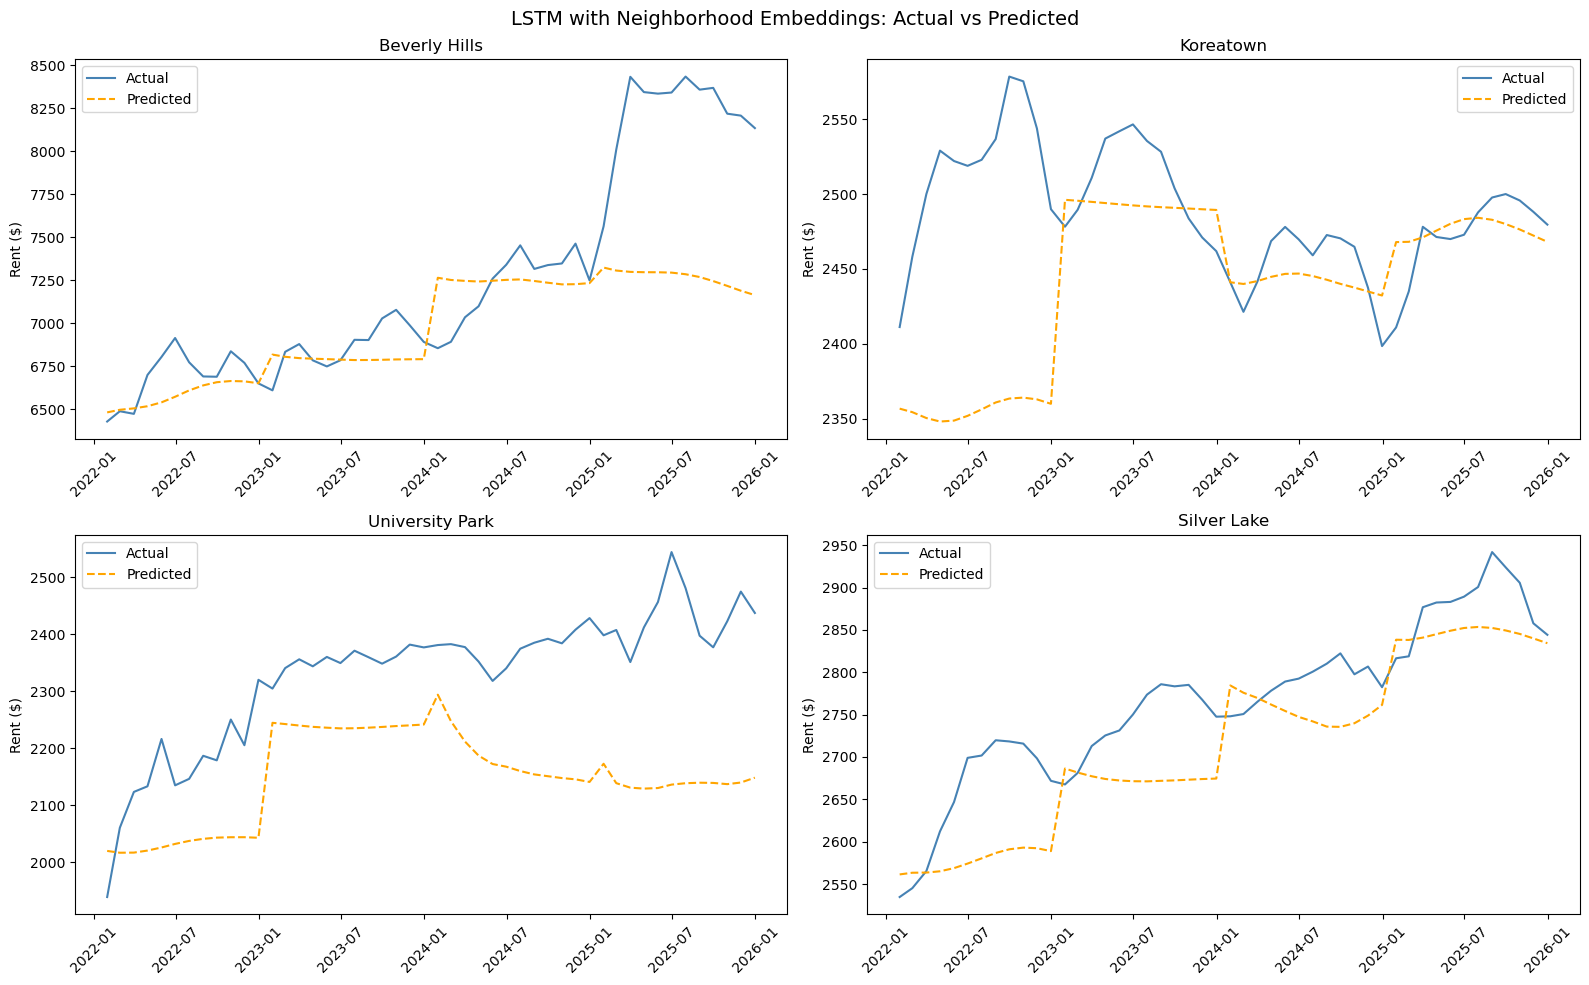


Predictions saved. Shape: (1056, 6)


In [34]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Load data ─────────────────────────────────────────────────────────────────
master = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master_model.csv')
master['Date'] = pd.to_datetime(master['Date'])
master = master.sort_values(['Neighborhood', 'Date']).reset_index(drop=True)

# ── Neighborhood integer encoding for embedding ───────────────────────────────
neighborhoods     = sorted(master['Neighborhood'].unique())
neighborhood_to_idx = {n: i for i, n in enumerate(neighborhoods)}
master['neighborhood_idx'] = master['Neighborhood'].map(neighborhood_to_idx)
NUM_NEIGHBORHOODS = len(neighborhoods)
EMBEDDING_DIM     = 8

# ── Per-neighborhood rent normalization ───────────────────────────────────────
stats = master.groupby('Neighborhood')['Rent'].agg(['mean', 'std']).reset_index()
stats.columns = ['Neighborhood', 'rent_mean', 'rent_std']
master = master.merge(stats, on='Neighborhood', how='left')
master['rent_normalized'] = (master['Rent'] - master['rent_mean']) / master['rent_std']

# ── Continuous feature columns ────────────────────────────────────────────────
CONTINUOUS_FEATURES = [
    'permits_trailing6', 'employment_growth', 'median_income',
    'renter_rate', 'covid', 'month', 'rent_yoy_growth'
]
SEQUENCE_LENGTH = 12

# ── Walk-forward folds ────────────────────────────────────────────────────────
folds = [
    ('2020-01-01', '2020-12-31', '2021-01-01', '2021-12-31'),
    ('2020-01-01', '2021-12-31', '2022-01-01', '2022-12-31'),
    ('2020-01-01', '2022-12-31', '2023-01-01', '2023-12-31'),
    ('2020-01-01', '2023-12-31', '2024-01-01', '2024-12-31'),
    ('2020-01-01', '2024-12-31', '2025-01-01', '2025-12-31'),
]

# ── Dataset ───────────────────────────────────────────────────────────────────
class RentDataset(Dataset):
    def __init__(self, sequences, neighborhood_ids, targets):
        self.sequences        = torch.tensor(sequences, dtype=torch.float32)
        self.neighborhood_ids = torch.tensor(neighborhood_ids, dtype=torch.long)
        self.targets          = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.sequences[idx], self.neighborhood_ids[idx], self.targets[idx]

# ── LSTM with embedding ───────────────────────────────────────────────────────
class LSTMWithEmbedding(nn.Module):
    def __init__(self, num_neighborhoods, embedding_dim, input_size,
                 hidden_size=128, num_layers=2, dropout=0.3):
        super(LSTMWithEmbedding, self).__init__()

        self.embedding = nn.Embedding(num_neighborhoods, embedding_dim)

        # LSTM input = continuous features + embedding
        self.lstm = nn.LSTM(
            input_size=input_size + embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x_seq, neighborhood_id):
        # Get neighborhood embedding — shape: (batch, embedding_dim)
        emb = self.embedding(neighborhood_id)

        # Expand embedding to match sequence length — shape: (batch, seq_len, embedding_dim)
        emb_expanded = emb.unsqueeze(1).expand(-1, x_seq.size(1), -1)

        # Concatenate embedding with features at each timestep
        x = torch.cat([x_seq, emb_expanded], dim=2)

        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out.squeeze()

# ── Sequence builder ──────────────────────────────────────────────────────────
def build_sequences(df, continuous_features, target_col, seq_len):
    """Build sequences strictly per neighborhood."""
    X_all, ids_all, y_all, meta = [], [], [], []

    for neighborhood, nd in df.groupby('Neighborhood'):
        nd = nd.sort_values('Date')

        if len(nd) <= seq_len:
            continue

        features  = nd[continuous_features].values.astype(np.float32)
        target    = nd[target_col].values.astype(np.float32)
        nd_idx    = nd['neighborhood_idx'].values[0]
        dates     = nd['Date'].values
        means     = nd['rent_mean'].values
        stds      = nd['rent_std'].values

        for i in range(seq_len, len(features)):
            X_all.append(features[i-seq_len:i])
            ids_all.append(nd_idx)
            y_all.append(target[i])
            meta.append({
                'Neighborhood': neighborhood,
                'Date':         dates[i],
                'rent_mean':    means[i],
                'rent_std':     stds[i],
            })

    return (np.array(X_all), np.array(ids_all),
            np.array(y_all), meta)

# ── Get last seq_len rows per neighborhood ────────────────────────────────────
def get_train_tail(df, seq_len):
    return (df.groupby('Neighborhood', group_keys=False)
              .apply(lambda x: x.sort_values('Date').tail(seq_len))
              .reset_index(drop=True))

# ── Scale continuous features ─────────────────────────────────────────────────
def scale_features(train_df, test_df, continuous_features):
    scaler   = MinMaxScaler()
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df[continuous_features] = scaler.fit_transform(train_df[continuous_features])
    test_df[continuous_features]  = scaler.transform(test_df[continuous_features])
    return train_df, test_df, scaler

# ── Training function ─────────────────────────────────────────────────────────
def train_lstm(model, train_loader, num_epochs=150, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        for x_seq, nd_ids, y_batch in train_loader:
            x_seq    = x_seq.to(device)
            nd_ids   = nd_ids.to(device)
            y_batch  = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(x_seq, nd_ids)
            loss  = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        scheduler.step(avg_loss)

        if (epoch + 1) % 30 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.6f}")

    return model

# ── Main training loop ────────────────────────────────────────────────────────
fold_results    = []
all_predictions = []

for i, (train_start, train_end, test_start, test_end) in enumerate(folds):
    print(f"\n── Fold {i+1} | Train: {train_start[:7]}→{train_end[:7]} | Test: {test_start[:7]}→{test_end[:7]} ──")

    train_df = master[(master['Date'] >= train_start) & (master['Date'] <= train_end)].copy()
    test_df  = master[(master['Date'] >= test_start)  & (master['Date'] <= test_end)].copy()

    # Skip fold if any neighborhood has less than seq_len+1 rows
    min_rows = train_df.groupby('Neighborhood').size().min()
    if min_rows <= SEQUENCE_LENGTH:
        print(f"  Skipping fold {i+1} — insufficient data ({min_rows} rows min)")
        continue

    # Scale continuous features
    train_df, test_df, scaler = scale_features(train_df, test_df, CONTINUOUS_FEATURES)

    # Build train sequences
    X_train, ids_train, y_train, _ = build_sequences(
        train_df, CONTINUOUS_FEATURES, 'rent_normalized', SEQUENCE_LENGTH
    )

    # Build test sequences with lookback context
    train_tail  = get_train_tail(train_df, SEQUENCE_LENGTH)
    combined_df = pd.concat([train_tail, test_df], ignore_index=True)

    X_test, ids_test, y_test, test_meta = build_sequences(
        combined_df, CONTINUOUS_FEATURES, 'rent_normalized', SEQUENCE_LENGTH
    )

    # Keep only test period dates
    test_dates = set(test_df['Date'].values)
    keep_idx   = [j for j, m in enumerate(test_meta) if m['Date'] in test_dates]
    X_test     = X_test[keep_idx]
    ids_test   = ids_test[keep_idx]
    y_test     = y_test[keep_idx]
    test_meta  = [test_meta[j] for j in keep_idx]

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"  Skipping fold {i+1} — no sequences built")
        continue

    print(f"  Train sequences: {len(X_train)} | Test sequences: {len(X_test)}")

    # DataLoader
    train_dataset = RentDataset(X_train, ids_train, y_train)
    train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=False)

    # Initialize model
    model = LSTMWithEmbedding(
        num_neighborhoods=NUM_NEIGHBORHOODS,
        embedding_dim=EMBEDDING_DIM,
        input_size=len(CONTINUOUS_FEATURES),
        hidden_size=128,
        num_layers=2,
        dropout=0.3
    ).to(device)

    # Train
    model = train_lstm(model, train_loader, num_epochs=150, lr=0.001)

    # Predict
    model.eval()
    with torch.no_grad():
        X_test_tensor   = torch.tensor(X_test, dtype=torch.float32).to(device)
        ids_test_tensor = torch.tensor(ids_test, dtype=torch.long).to(device)
        preds_norm      = model(X_test_tensor, ids_test_tensor).cpu().numpy()

    # Back-transform per neighborhood
    preds_rent  = []
    actual_rent = []

    for j, meta in enumerate(test_meta):
        pred_r   = float(preds_norm[j]) * meta['rent_std'] + meta['rent_mean']
        actual_r = float(y_test[j])     * meta['rent_std'] + meta['rent_mean']
        preds_rent.append(pred_r)
        actual_rent.append(actual_r)

    preds_rent  = np.array(preds_rent)
    actual_rent = np.array(actual_rent)

    # Metrics
    mae  = mean_absolute_error(actual_rent, preds_rent)
    rmse = np.sqrt(mean_squared_error(actual_rent, preds_rent))
    mape = np.mean(np.abs((actual_rent - preds_rent) / actual_rent)) * 100
    r2   = r2_score(actual_rent, preds_rent)

    dir_actual = np.sign(np.diff(actual_rent))
    dir_pred   = np.sign(np.diff(preds_rent))
    dir_acc    = np.mean(dir_actual == dir_pred) * 100

    fold_results.append({
        'Fold':         i + 1,
        'Train period': f"{train_start[:7]} → {train_end[:7]}",
        'Test period':  f"{test_start[:7]} → {test_end[:7]}",
        'MAE':          round(mae, 2),
        'RMSE':         round(rmse, 2),
        'MAPE':         round(mape, 2),
        'R²':           round(r2, 3),
        'Dir Acc %':    round(dir_acc, 1),
    })

    for j, meta in enumerate(test_meta):
        all_predictions.append({
            'Neighborhood':   meta['Neighborhood'],
            'Date':           meta['Date'],
            'Rent':           actual_rent[j],
            'predicted_rent': preds_rent[j],
            'residual':       actual_rent[j] - preds_rent[j],
            'fold':           i + 1,
        })

    print(f"  MAE: ${mae:.0f} | RMSE: ${rmse:.0f} | MAPE: {mape:.2f}% | R²: {r2:.3f} | Dir Acc: {dir_acc:.1f}%")

# ── Results summary ───────────────────────────────────────────────────────────
results_df = pd.DataFrame(fold_results)
print(f"\n── LSTM Embedding Results ──")
print(results_df.to_string(index=False))
print(f"\nMean MAE:     ${results_df['MAE'].mean():.0f}")
print(f"Mean RMSE:    ${results_df['RMSE'].mean():.0f}")
print(f"Mean MAPE:    {results_df['MAPE'].mean():.2f}%")
print(f"Mean R²:      {results_df['R²'].mean():.3f}")
print(f"Mean Dir Acc: {results_df['Dir Acc %'].mean():.1f}%")

# ── Combine predictions ───────────────────────────────────────────────────────
predictions_df = pd.DataFrame(all_predictions)
predictions_df['Date'] = pd.to_datetime(predictions_df['Date'])

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"\nNeighborhoods in predictions: {predictions_df['Neighborhood'].nunique()}")
print(predictions_df['Neighborhood'].value_counts())

# ── Plot: Actual vs Predicted ─────────────────────────────────────────────────
sample_neighborhoods = ['Beverly Hills', 'Koreatown', 'University Park', 'Silver Lake']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, neighborhood in enumerate(sample_neighborhoods):
    ax = axes[i]
    nd = predictions_df[predictions_df['Neighborhood'] == neighborhood].sort_values('Date')

    if nd.empty:
        ax.set_title(f"{neighborhood} — no predictions")
        continue

    ax.plot(nd['Date'], nd['Rent'], label='Actual', color='steelblue')
    ax.plot(nd['Date'], nd['predicted_rent'], label='Predicted',
            color='orange', linestyle='--')
    ax.set_title(neighborhood)
    ax.legend()
    ax.set_ylabel('Rent ($)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('LSTM with Neighborhood Embeddings: Actual vs Predicted', fontsize=14)
plt.tight_layout()
plt.show()

# ── Save predictions ──────────────────────────────────────────────────────────
predictions_df.to_csv(
    '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/model_csv/lstm_final_predictions.csv',
    index=False
)
print(f"\nPredictions saved. Shape: {predictions_df.shape}")

# ENSEMBLE

In [39]:
import pandas as pd

xgb     = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/model_csv/xgb_final_predictions.csv')
prophet = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/model_csv/prophet_final_predictions.csv')
lstm    = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/model_csv/lstm_final_predictions.csv')

# ── Recover Neighborhood column for XGBoost ───────────────────────────────────
neighborhood_cols = [c for c in xgb.columns if c.startswith('Neighborhood_')]

def recover_neighborhood(row):
    for col in neighborhood_cols:
        if row[col] == 1:
            return col.replace('Neighborhood_', '')
    return 'Beverly Hills'  # reference category — all dummies = 0

xgb['Neighborhood'] = xgb.apply(recover_neighborhood, axis=1)

# ── Keep only essential columns ───────────────────────────────────────────────
xgb     = xgb[['Neighborhood', 'Date', 'Rent', 'predicted_rent']].copy()
prophet = prophet[['Neighborhood', 'Date', 'Rent', 'predicted_rent']].copy()
lstm    = lstm[['Neighborhood', 'Date', 'Rent', 'predicted_rent']].copy()

# ── Verify ────────────────────────────────────────────────────────────────────
for name, df in [('XGBoost', xgb), ('Prophet', prophet), ('LSTM', lstm)]:
    print(f"\n{name}:")
    print(f"  Shape: {df.shape}")
    print(f"  Neighborhoods: {df['Neighborhood'].nunique()}")
    print(f"  Date range: {df['Date'].min()} to {df['Date'].max()}")


XGBoost:
  Shape: (1320, 4)
  Neighborhoods: 22
  Date range: 2021-01-31 to 2025-12-31

Prophet:
  Shape: (1056, 4)
  Neighborhoods: 22
  Date range: 2022-01-31 to 2025-12-31

LSTM:
  Shape: (1056, 4)
  Neighborhoods: 22
  Date range: 2022-01-31 to 2025-12-31


In [51]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base = '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/model_csv/'

# ── Load ──────────────────────────────────────────────────────────────────────
xgb     = pd.read_csv(base + 'xgb_final_predictions.csv')
prophet = pd.read_csv(base + 'prophet_final_predictions.csv')
lstm    = pd.read_csv(base + 'lstm_final_predictions.csv')

# ── Recover Neighborhood for XGBoost ─────────────────────────────────────────
neighborhood_cols = [c for c in xgb.columns if c.startswith('Neighborhood_')]
def recover_neighborhood(row):
    for col in neighborhood_cols:
        if row[col] == 1:
            return col.replace('Neighborhood_', '')
    return 'Beverly Hills'
xgb['Neighborhood'] = xgb.apply(recover_neighborhood, axis=1)

# ── Keep only needed columns ──────────────────────────────────────────────────
xgb     = xgb[['Neighborhood', 'Date', 'Rent', 'predicted_rent', 'fold']].copy()
prophet = prophet[['Neighborhood', 'Date', 'Rent', 'predicted_rent', 'fold']].copy()
lstm    = lstm[['Neighborhood', 'Date', 'Rent', 'predicted_rent', 'fold']].copy()

# ── Deduplicate — keep latest fold per neighborhood-month ─────────────────────
xgb     = xgb.sort_values('fold').groupby(['Neighborhood', 'Date']).last().reset_index()
prophet = prophet.sort_values('fold').groupby(['Neighborhood', 'Date']).last().reset_index()
lstm    = lstm.sort_values('fold').groupby(['Neighborhood', 'Date']).last().reset_index()

# ── Verify ────────────────────────────────────────────────────────────────────
for name, df in [('XGBoost', xgb), ('Prophet', prophet), ('LSTM', lstm)]:
    print(f"{name}: {df.shape} | Neighborhoods: {df['Neighborhood'].nunique()} | Dates: {df['Date'].min()} → {df['Date'].max()}")

# ── Merge on Neighborhood + Date ──────────────────────────────────────────────
ensemble = xgb[['Neighborhood', 'Date', 'Rent', 'predicted_rent']].merge(
    prophet[['Neighborhood', 'Date', 'predicted_rent']],
    on=['Neighborhood', 'Date'],
    how='inner',
    suffixes=('_xgb', '_prophet')
)
ensemble = ensemble.merge(
    lstm[['Neighborhood', 'Date', 'predicted_rent']],
    on=['Neighborhood', 'Date'],
    how='inner'
)
ensemble = ensemble.rename(columns={'predicted_rent': 'predicted_lstm'})

print(f"\nEnsemble shape: {ensemble.shape}")
print(f"Missing values:\n{ensemble.isnull().sum()}")

# ── Inverse-MAPE weighted average ────────────────────────────────────────────
w_xgb     = 1 / 4.92
w_prophet = 1 / 4.45
w_lstm    = 1 / 3.97
w_total   = w_xgb + w_prophet + w_lstm

ensemble['predicted_ensemble'] = (
    w_xgb     * ensemble['predicted_rent_xgb'] +
    w_prophet * ensemble['predicted_rent_prophet'] +
    w_lstm    * ensemble['predicted_lstm']
) / w_total

# ── Residuals ─────────────────────────────────────────────────────────────────
ensemble['residual'] = ensemble['Rent'] - ensemble['predicted_ensemble']

# ── Metrics ───────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(ensemble['Rent'], ensemble['predicted_ensemble'])
rmse = np.sqrt(mean_squared_error(ensemble['Rent'], ensemble['predicted_ensemble']))
mape = np.mean(np.abs((ensemble['Rent'] - ensemble['predicted_ensemble']) / ensemble['Rent'])) * 100
r2   = r2_score(ensemble['Rent'], ensemble['predicted_ensemble'])

print(f"\n── Ensemble Metrics ──")
print(f"MAE:  ${mae:.0f}")
print(f"RMSE: ${rmse:.0f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.3f}")

# ── Save ──────────────────────────────────────────────────────────────────────
ensemble.to_csv(base + 'ensemble_predictions.csv', index=False)
print(f"\nEnsemble saved. Shape: {ensemble.shape}")

XGBoost: (1320, 5) | Neighborhoods: 22 | Dates: 2021-01-31 → 2025-12-31
Prophet: (1056, 5) | Neighborhoods: 22 | Dates: 2022-01-31 → 2025-12-31
LSTM: (1056, 5) | Neighborhoods: 22 | Dates: 2022-01-31 → 2025-12-31

Ensemble shape: (1056, 6)
Missing values:
Neighborhood              0
Date                      0
Rent                      0
predicted_rent_xgb        0
predicted_rent_prophet    0
predicted_lstm            0
dtype: int64

── Ensemble Metrics ──
MAE:  $84
RMSE: $142
MAPE: 2.66%
R²:   0.982

Ensemble saved. Shape: (1056, 8)


Ensemble shape: (1056, 8)
Columns: ['Neighborhood', 'Date', 'Rent', 'predicted_rent_xgb', 'predicted_rent_prophet', 'predicted_lstm', 'predicted_ensemble', 'residual']
Beverly Hills: 0 anomalies flagged (0.0%)
Boyle Heights: 10 anomalies flagged (20.8%)
Brentwood: 2 anomalies flagged (4.2%)
Culver City: 1 anomalies flagged (2.1%)
Downtown LA: 1 anomalies flagged (2.1%)
Exposition Park: 15 anomalies flagged (31.2%)
Glassell Park: 17 anomalies flagged (35.4%)
Hancock Park: 3 anomalies flagged (6.2%)
Highland Park: 1 anomalies flagged (2.1%)
Koreatown: 0 anomalies flagged (0.0%)
Leimert Park: 3 anomalies flagged (6.2%)
Los Feliz: 11 anomalies flagged (22.9%)
Mar Vista: 2 anomalies flagged (4.2%)
Mid-Wilshire: 2 anomalies flagged (4.2%)
Palms: 2 anomalies flagged (4.2%)
Santa Monica: 2 anomalies flagged (4.2%)
Silver Lake: 1 anomalies flagged (2.1%)
University Park: 7 anomalies flagged (14.6%)
Vermont Square: 6 anomalies flagged (12.5%)
West Adams: 5 anomalies flagged (10.4%)
West Hollywoo

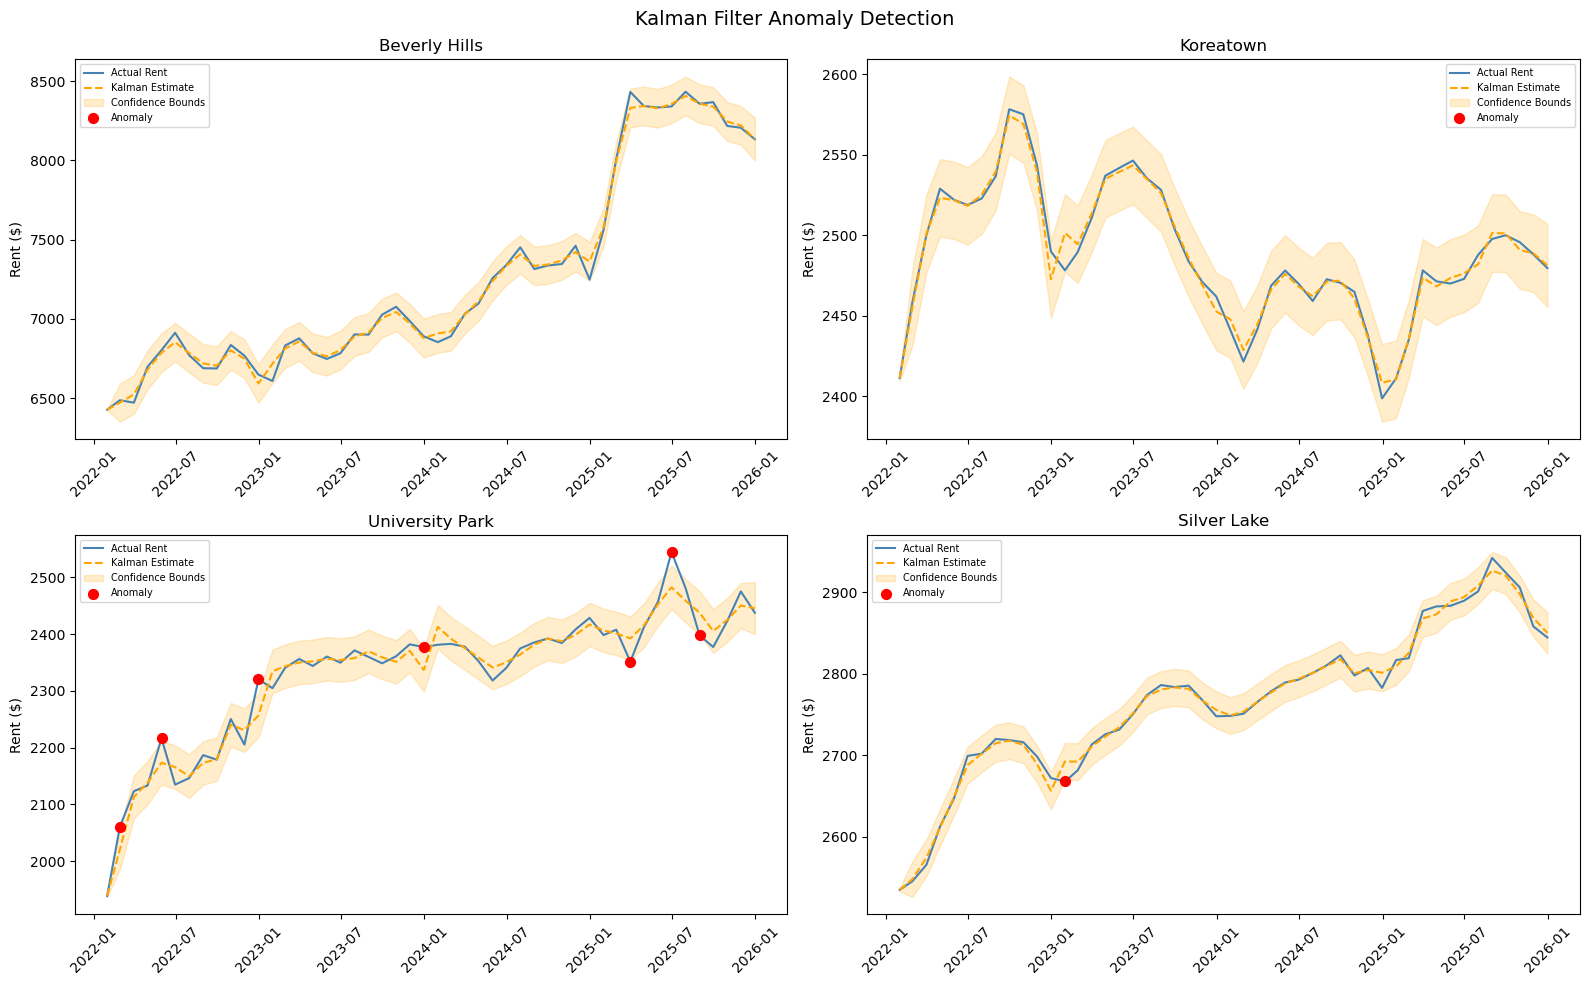


Anomaly results saved. Shape: (1056, 14)


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

# ── Load ensemble predictions ─────────────────────────────────────────────────
base     = '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/model_csv/'
ensemble = pd.read_csv(base + 'ensemble_predictions.csv')
ensemble['Date'] = pd.to_datetime(ensemble['Date'])
ensemble = ensemble.sort_values(['Neighborhood', 'Date']).reset_index(drop=True)

print(f"Ensemble shape: {ensemble.shape}")
print(f"Columns: {list(ensemble.columns)}")

# ── Kalman Filter per neighborhood ────────────────────────────────────────────
# Parameters
PROCESS_NOISE      = 0.01   # Q — how much rent naturally drifts month to month
OBSERVATION_NOISE  = 0.1    # R — how noisy are ensemble predictions
ANOMALY_THRESHOLD  = 2.0    # number of standard deviations for anomaly flag

all_kalman = []

for neighborhood, nd in ensemble.groupby('Neighborhood'):
    nd = nd.sort_values('Date').copy()

    # Use ensemble residuals as observations
    observations = nd['residual'].values.reshape(-1, 1)

    # ── Initialize Kalman Filter ──────────────────────────────────────────────
    kf = KalmanFilter(
        transition_matrices    = [[1]],          # state transition — rent persists
        observation_matrices   = [[1]],          # observation model
        transition_covariance  = [[PROCESS_NOISE]],
        observation_covariance = [[OBSERVATION_NOISE]],
        initial_state_mean     = [observations[0, 0]],
        initial_state_covariance = [[1]],
        em_vars=['transition_covariance', 'observation_covariance']
    )

    # ── Fit and smooth ────────────────────────────────────────────────────────
    # Use EM algorithm to learn optimal Q and R from data
    kf = kf.em(observations, n_iter=10)

    # Get smoothed state estimates and covariances
    smoothed_means, smoothed_covs = kf.smooth(observations)

    # ── Compute dynamic confidence bounds ─────────────────────────────────────
    smoothed_std = np.sqrt(smoothed_covs[:, 0, 0])

    kalman_estimate = nd['predicted_ensemble'].values + smoothed_means[:, 0]
    upper_bound     = kalman_estimate + ANOMALY_THRESHOLD * smoothed_std
    lower_bound     = kalman_estimate - ANOMALY_THRESHOLD * smoothed_std

    # ── Flag anomalies ────────────────────────────────────────────────────────
    actual          = nd['Rent'].values
    is_anomaly      = (actual > upper_bound) | (actual < lower_bound)
    anomaly_score   = np.abs(actual - kalman_estimate) / (smoothed_std + 1e-8)

    # ── Store results ─────────────────────────────────────────────────────────
    nd = nd.copy()
    nd['kalman_estimate'] = kalman_estimate
    nd['upper_bound']     = upper_bound
    nd['lower_bound']     = lower_bound
    nd['smoothed_std']    = smoothed_std
    nd['anomaly_score']   = anomaly_score
    nd['is_anomaly']      = is_anomaly

    all_kalman.append(nd)

    n_anomalies = is_anomaly.sum()
    print(f"{neighborhood}: {n_anomalies} anomalies flagged ({n_anomalies/len(nd)*100:.1f}%)")

# ── Combine all neighborhoods ─────────────────────────────────────────────────
kalman_df = pd.concat(all_kalman, ignore_index=True)

print(f"\nTotal anomalies flagged: {kalman_df['is_anomaly'].sum()}")
print(f"Anomaly rate: {kalman_df['is_anomaly'].mean()*100:.1f}%")
print(f"\nTop anomalies by score:")
print(kalman_df[kalman_df['is_anomaly']]
      .sort_values('anomaly_score', ascending=False)
      [['Neighborhood', 'Date', 'Rent', 'kalman_estimate', 'anomaly_score']]
      .head(20)
      .to_string(index=False))

# ── Plot: Anomaly detection for sample neighborhoods ─────────────────────────
sample_neighborhoods = ['Beverly Hills', 'Koreatown', 'University Park', 'Silver Lake']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, neighborhood in enumerate(sample_neighborhoods):
    ax  = axes[i]
    nd  = kalman_df[kalman_df['Neighborhood'] == neighborhood].sort_values('Date')
    anomalies = nd[nd['is_anomaly']]

    # Plot actual rent
    ax.plot(nd['Date'], nd['Rent'],
            label='Actual Rent', color='steelblue', linewidth=1.5)

    # Plot Kalman estimate
    ax.plot(nd['Date'], nd['kalman_estimate'],
            label='Kalman Estimate', color='orange',
            linestyle='--', linewidth=1.5)

    # Plot confidence bounds
    ax.fill_between(nd['Date'], nd['lower_bound'], nd['upper_bound'],
                    alpha=0.2, color='orange', label='Confidence Bounds')

    # Plot anomalies
    ax.scatter(anomalies['Date'], anomalies['Rent'],
               color='red', zorder=5, s=50, label='Anomaly')

    ax.set_title(neighborhood)
    ax.legend(fontsize=7)
    ax.set_ylabel('Rent ($)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Kalman Filter Anomaly Detection', fontsize=14)
plt.tight_layout()
plt.show()

# ── Save results ──────────────────────────────────────────────────────────────
kalman_df.to_csv(base + 'anomaly_results.csv', index=False)
print(f"\nAnomaly results saved. Shape: {kalman_df.shape}")

# FINAL XGBoost

In [54]:
import joblib
import os

# ── XGBoost Final Model — train on full 2020–2025 data ───────────────────────
print("Training final XGBoost model...")

master_final = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master_model.csv')
master_final['Date'] = pd.to_datetime(master_final['Date'])
master_final = master_final.sort_values(['Neighborhood', 'Date']).reset_index(drop=True)

# One-hot encode
master_final = pd.get_dummies(master_final, columns=['Neighborhood'], drop_first=True)
neighborhood_cols_final = [c for c in master_final.columns if c.startswith('Neighborhood_')]
master_final[neighborhood_cols_final] = master_final[neighborhood_cols_final].astype(int)

FEATURES_FINAL = neighborhood_cols_final + [
    'permits_trailing6', 'employment_growth', 'median_income',
    'renter_rate', 'covid', 'month', 'rent_yoy_growth'
]

X_final = master_final[FEATURES_FINAL]
y_final = master_final['Rent']

xgb_final = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_final.fit(X_final, y_final, verbose=False)

# Save
models_path = '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/models/'
os.makedirs(models_path, exist_ok=True)
joblib.dump(xgb_final, models_path + 'xgb_final.pkl')
joblib.dump(FEATURES_FINAL, models_path + 'xgb_features.pkl')
print(f"XGBoost final saved. Trained on {len(X_final)} rows.")

Training final XGBoost model...
XGBoost final saved. Trained on 1584 rows.


# FINAL Prophet

In [56]:
import joblib
import logging
from prophet import Prophet

logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

models_path = '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/models/'

print("Training final Prophet models...")

master_prophet = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master_model.csv')
master_prophet['Date'] = pd.to_datetime(master_prophet['Date'])
master_prophet = master_prophet.sort_values(['Neighborhood', 'Date']).reset_index(drop=True)

prophet_models_final = {}

for neighborhood in sorted(master_prophet['Neighborhood'].unique()):
    nd = master_prophet[master_prophet['Neighborhood'] == neighborhood].copy()
    nd = nd.rename(columns={'Date': 'ds', 'Rent': 'y'})

    floor = nd['y'].min() * 0.7
    cap   = nd['y'].max() * 1.5
    nd['floor'] = floor
    nd['cap']   = cap

    m = Prophet(
        growth='logistic',
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
    )
    m.add_seasonality(name='yearly', period=365.25, fourier_order=3)
    m.fit(nd[['ds', 'y', 'floor', 'cap']])

    prophet_models_final[neighborhood] = {
        'model': m,
        'floor': floor,
        'cap':   cap
    }
    print(f"  {neighborhood} done")

joblib.dump(prophet_models_final, models_path + 'prophet_final.pkl')
print(f"\nProphet final saved. {len(prophet_models_final)} neighborhood models.")

Training final Prophet models...
  Beverly Hills done
  Boyle Heights done
  Brentwood done
  Culver City done
  Downtown LA done
  Exposition Park done
  Glassell Park done
  Hancock Park done
  Highland Park done
  Koreatown done
  Leimert Park done
  Los Feliz done
  Mar Vista done
  Mid-Wilshire done
  Palms done
  Santa Monica done
  Silver Lake done
  University Park done
  Vermont Square done
  West Adams done
  West Hollywood done
  Westwood done

Prophet final saved. 22 neighborhood models.


# Final LSTM

In [57]:
import torch
import joblib
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader

print("Training final LSTM model...")

models_path = '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/models/'

master_lstm = pd.read_csv('/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/master_model.csv')
master_lstm['Date'] = pd.to_datetime(master_lstm['Date'])
master_lstm = master_lstm.sort_values(['Neighborhood', 'Date']).reset_index(drop=True)

# ── Neighborhood encoding ─────────────────────────────────────────────────────
neighborhoods_final = sorted(master_lstm['Neighborhood'].unique())
n_to_idx_final      = {n: i for i, n in enumerate(neighborhoods_final)}
master_lstm['neighborhood_idx'] = master_lstm['Neighborhood'].map(n_to_idx_final)

# ── Per-neighborhood rent normalization ───────────────────────────────────────
stats_final = master_lstm.groupby('Neighborhood')['Rent'].agg(['mean', 'std']).reset_index()
stats_final.columns = ['Neighborhood', 'rent_mean', 'rent_std']
master_lstm = master_lstm.merge(stats_final, on='Neighborhood', how='left')
master_lstm['rent_normalized'] = (master_lstm['Rent'] - master_lstm['rent_mean']) / master_lstm['rent_std']

# ── Scale continuous features ─────────────────────────────────────────────────
CONTINUOUS_FEATURES_FINAL = [
    'permits_trailing6', 'employment_growth', 'median_income',
    'renter_rate', 'covid', 'month', 'rent_yoy_growth'
]

scaler_final = MinMaxScaler()
master_lstm[CONTINUOUS_FEATURES_FINAL] = scaler_final.fit_transform(
    master_lstm[CONTINUOUS_FEATURES_FINAL]
)

# ── Build sequences ───────────────────────────────────────────────────────────
X_all, ids_all, y_all, _ = build_sequences(
    master_lstm, CONTINUOUS_FEATURES_FINAL, 'rent_normalized', SEQUENCE_LENGTH
)
print(f"Total sequences: {len(X_all)}")

# ── Train ─────────────────────────────────────────────────────────────────────
train_dataset_final = RentDataset(X_all, ids_all, y_all)
train_loader_final  = DataLoader(train_dataset_final, batch_size=32, shuffle=False)

lstm_final = LSTMWithEmbedding(
    num_neighborhoods=len(neighborhoods_final),
    embedding_dim=EMBEDDING_DIM,
    input_size=len(CONTINUOUS_FEATURES_FINAL),
    hidden_size=128,
    num_layers=2,
    dropout=0.3
).to(device)

lstm_final = train_lstm(lstm_final, train_loader_final, num_epochs=150, lr=0.001)

# ── Save ──────────────────────────────────────────────────────────────────────
torch.save(lstm_final.state_dict(),  models_path + 'lstm_final.pt')
joblib.dump(scaler_final,            models_path + 'lstm_scaler.pkl')
joblib.dump(stats_final,             models_path + 'lstm_neighborhood_stats.pkl')
joblib.dump(n_to_idx_final,          models_path + 'lstm_neighborhood_idx.pkl')
joblib.dump(neighborhoods_final,     models_path + 'lstm_neighborhoods.pkl')

print(f"\nLSTM final saved.")
print(f"Files saved to: {models_path}")

Training final LSTM model...
Total sequences: 1320
  Epoch 30/150 | Loss: 0.136779
  Epoch 60/150 | Loss: 0.098251
  Epoch 90/150 | Loss: 0.069812
  Epoch 120/150 | Loss: 0.046358
  Epoch 150/150 | Loss: 0.041416

LSTM final saved.
Files saved to: /Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/models/


# KALMAN

In [60]:
import joblib

models_path = '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/models/'

# ── Save Kalman last known state per neighborhood ─────────────────────────────
kalman_last_state = kalman_df.sort_values('Date').groupby('Neighborhood').last()[
    ['kalman_estimate', 'upper_bound', 'lower_bound', 'smoothed_std']
].reset_index()

joblib.dump(kalman_last_state, models_path + 'kalman_last_state.pkl')
print("Kalman last state saved:")
print(kalman_last_state[['Neighborhood', 'kalman_estimate', 'smoothed_std']].to_string(index=False))

Kalman last state saved:
   Neighborhood  kalman_estimate  smoothed_std
  Beverly Hills      8133.766163     67.224075
  Boyle Heights      2351.704954     23.360599
      Brentwood      4046.839882     35.323763
    Culver City      3334.299372     15.757213
    Downtown LA      2534.472954     10.782314
Exposition Park      2450.142031     17.345899
  Glassell Park      2845.401078     17.228265
   Hancock Park      2250.337334     13.059891
  Highland Park      2850.110330     10.076403
      Koreatown      2481.238392     12.939116
   Leimert Park      2235.438721     18.864711
      Los Feliz      2674.262931     12.230519
      Mar Vista      3139.994843     15.335278
   Mid-Wilshire      2821.329345     19.337103
          Palms      2668.841082     16.036842
   Santa Monica      3606.366010     12.956443
    Silver Lake      2849.846306     12.662586
University Park      2445.838809     22.904432
 Vermont Square      2344.162843     20.088385
     West Adams      2944.467454   

# TEST MODELS:

In [59]:
import joblib
import torch
import numpy as np
import pandas as pd

models_path = '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/models/'
data_path   = '/Users/karim/Documents/la-rent-anomaly-detection/la-rent-anomaly-detection/data/processed/'

# ── Load all models ───────────────────────────────────────────────────────────
xgb_model       = joblib.load(models_path + 'xgb_final.pkl')
xgb_features    = joblib.load(models_path + 'xgb_features.pkl')
prophet_models  = joblib.load(models_path + 'prophet_final.pkl')
lstm_scaler     = joblib.load(models_path + 'lstm_scaler.pkl')
lstm_stats      = joblib.load(models_path + 'lstm_neighborhood_stats.pkl')
lstm_n_to_idx   = joblib.load(models_path + 'lstm_neighborhood_idx.pkl')
lstm_neighbors  = joblib.load(models_path + 'lstm_neighborhoods.pkl')

# Rebuild LSTM model architecture and load weights
lstm_model = LSTMWithEmbedding(
    num_neighborhoods=len(lstm_neighbors),
    embedding_dim=8,
    input_size=7,  # number of continuous features
    hidden_size=128,
    num_layers=2,
    dropout=0.3
).to(device)
lstm_model.load_state_dict(torch.load(models_path + 'lstm_final.pt'))
lstm_model.eval()

print("All models loaded successfully")

# ── Test inputs ───────────────────────────────────────────────────────────────
# Simulate a user inputting: Koreatown, June 2024, $2,600
TEST_NEIGHBORHOOD = 'Koreatown'
TEST_DATE         = '2024-06-30'
TEST_RENT         = 2600

# ── Fetch features from master_model.csv (historical mode) ───────────────────
master = pd.read_csv(data_path + 'master_model.csv')
master['Date'] = pd.to_datetime(master['Date'])

row = master[
    (master['Neighborhood'] == TEST_NEIGHBORHOOD) &
    (master['Date'] == TEST_DATE)
]

if row.empty:
    print(f"No data found for {TEST_NEIGHBORHOOD} on {TEST_DATE}")
else:
    print(f"\nTest: {TEST_NEIGHBORHOOD} | {TEST_DATE} | User rent: ${TEST_RENT}")
    print(f"Features found:\n{row[['permits_trailing6', 'employment_growth', 'median_income', 'renter_rate', 'covid', 'month', 'rent_yoy_growth']].to_string()}")

    # ── XGBoost prediction ────────────────────────────────────────────────────
    master_encoded = pd.get_dummies(master, columns=['Neighborhood'], drop_first=True)
    neighborhood_cols_test = [c for c in master_encoded.columns if c.startswith('Neighborhood_')]
    master_encoded[neighborhood_cols_test] = master_encoded[neighborhood_cols_test].astype(int)

    row_encoded = master_encoded[master_encoded['Date'] == TEST_DATE]
    row_encoded = row_encoded[row_encoded[f'Neighborhood_{TEST_NEIGHBORHOOD}'] == 1] if f'Neighborhood_{TEST_NEIGHBORHOOD}' in row_encoded.columns else row_encoded[row_encoded[neighborhood_cols_test].sum(axis=1) == 0]

    xgb_pred = xgb_model.predict(row_encoded[xgb_features])[0]
    print(f"\nXGBoost predicted rent: ${xgb_pred:.0f}")

    # ── Prophet prediction ────────────────────────────────────────────────────
    prophet_info = prophet_models[TEST_NEIGHBORHOOD]
    future_df = pd.DataFrame({
        'ds':    [pd.Timestamp(TEST_DATE)],
        'floor': [prophet_info['floor']],
        'cap':   [prophet_info['cap']]
    })
    prophet_forecast = prophet_info['model'].predict(future_df)
    prophet_pred     = prophet_forecast['yhat'].values[0]
    print(f"Prophet predicted rent:  ${prophet_pred:.0f}")

    # ── LSTM prediction ───────────────────────────────────────────────────────
    # Get last 12 months of data for this neighborhood as sequence
    nd_history = master[master['Neighborhood'] == TEST_NEIGHBORHOOD].copy()
    nd_history = nd_history.sort_values('Date')
    nd_history = nd_history[nd_history['Date'] <= TEST_DATE].tail(12)

    CONTINUOUS_FEATURES = [
        'permits_trailing6', 'employment_growth', 'median_income',
        'renter_rate', 'covid', 'month', 'rent_yoy_growth'
    ]

    if len(nd_history) == 12:
        seq_features = lstm_scaler.transform(nd_history[CONTINUOUS_FEATURES].values)
        seq_tensor   = torch.tensor(seq_features, dtype=torch.float32).unsqueeze(0).to(device)
        nd_idx       = torch.tensor([lstm_n_to_idx[TEST_NEIGHBORHOOD]], dtype=torch.long).to(device)

        with torch.no_grad():
            pred_norm = float(lstm_model(seq_tensor, nd_idx).cpu().numpy())

        nd_stats   = lstm_stats[lstm_stats['Neighborhood'] == TEST_NEIGHBORHOOD].iloc[0]
        lstm_pred  = pred_norm * nd_stats['rent_std'] + nd_stats['rent_mean']
        print(f"LSTM predicted rent:     ${lstm_pred:.0f}")
    else:
        lstm_pred = (xgb_pred + prophet_pred) / 2
        print(f"LSTM skipped — insufficient history, using XGBoost/Prophet average")

    # ── Ensemble ──────────────────────────────────────────────────────────────
    w_xgb     = 1 / 4.92
    w_prophet = 1 / 4.45
    w_lstm    = 1 / 3.97
    w_total   = w_xgb + w_prophet + w_lstm

    ensemble_pred = (
        w_xgb * xgb_pred + w_prophet * prophet_pred + w_lstm * lstm_pred
    ) / w_total

    print(f"\nEnsemble predicted rent: ${ensemble_pred:.0f}")

    # ── Kalman bounds ─────────────────────────────────────────────────────────
    anomaly_results = pd.read_csv(data_path.replace('processed', 'model_csv') + 'anomaly_results.csv')
    anomaly_results['Date'] = pd.to_datetime(anomaly_results['Date'])

    kalman_row = anomaly_results[
        (anomaly_results['Neighborhood'] == TEST_NEIGHBORHOOD) &
        (anomaly_results['Date'] == TEST_DATE)
    ]

    if not kalman_row.empty:
        lower = kalman_row['lower_bound'].values[0]
        upper = kalman_row['upper_bound'].values[0]
        is_anomaly = TEST_RENT > upper or TEST_RENT < lower

        print(f"Kalman bounds:           [${lower:.0f}, ${upper:.0f}]")
        print(f"User rent:               ${TEST_RENT}")
        print(f"\n{'🚨 ANOMALY DETECTED' if is_anomaly else '✅ NORMAL — within expected range'}")
        print(f"Deviation from ensemble: ${abs(TEST_RENT - ensemble_pred):.0f}")
    else:
        print(f"No Kalman bounds found for this date")

All models loaded successfully

Test: Koreatown | 2024-06-30 | User rent: $2600
Features found:
     permits_trailing6  employment_growth  median_income  renter_rate  covid  month  rent_yoy_growth
701              187.0          -0.628751       53314.86       0.8997      0      6        -3.013029

XGBoost predicted rent: $2469
Prophet predicted rent:  $2483
LSTM predicted rent:     $2512

Ensemble predicted rent: $2489
Kalman bounds:           [$2444, $2492]
User rent:               $2600

🚨 ANOMALY DETECTED
Deviation from ensemble: $111
